# Regressão Logística

## Classificação Binária: Spam ou Não Spam?


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Criando o dataset de e-mails

Vamos gerar dados sintéticos simulando e-mails com palavras típicas de spam.

In [3]:
np.random.seed(42)
n = 500

num_palavras_spam = np.random.poisson(lam=8, size=n)
num_palavras_spam[num_palavras_spam > 15] = 15

tem_ganhe     = np.random.binomial(1, 0.6, n)
tem_premio    = np.random.binomial(1, 0.5, n)
tem_urgente   = np.random.binomial(1, 0.4, n)
tem_dinheiro  = np.random.binomial(1, 0.5, n)
tem_gratis    = np.random.binomial(1, 0.7, n)
tem_clique    = np.random.binomial(1, 0.5, n)
tem_oferta    = np.random.binomial(1, 0.4, n)
tem_exclusivo = np.random.binomial(1, 0.3, n)
tem_desconto  = np.random.binomial(1, 0.3, n)
tem_link      = np.random.binomial(1, 0.8, n)

spam_score = (
    num_palavras_spam * 0.5 +
    tem_ganhe * 3 + tem_premio * 2.5 + tem_urgente * 2 +
    tem_dinheiro * 3 + tem_gratis * 2 + tem_clique * 1.5 +
    tem_oferta * 1.5 + tem_exclusivo * 1 + tem_desconto * 1 +
    tem_link * 1.5 + np.random.normal(0, 1, n)
)

prob_spam = 1 / (1 + np.exp(-spam_score + 6))
spam = (prob_spam > 0.5).astype(int)

emails = pd.DataFrame({
    'num_palavras_spam': num_palavras_spam,
    'tem_ganhe': tem_ganhe,
    'tem_premio': tem_premio,
    'tem_urgente': tem_urgente,
    'tem_dinheiro': tem_dinheiro,
    'tem_gratis': tem_gratis,
    'tem_clique': tem_clique,
    'tem_oferta': tem_oferta,
    'tem_exclusivo': tem_exclusivo,
    'tem_desconto': tem_desconto,
    'tem_link': tem_link,
    'spam': spam
})

print(f'Total de e-mails: {len(emails)}')
print(f'Spam: {emails["spam"].sum()} ({emails["spam"].mean()*100:.1f}%)')
print(f'Não Spam: {(1 - emails["spam"]).sum()} ({(1 - emails["spam"]).mean()*100:.1f}%)')
emails.head(10)

Total de e-mails: 500
Spam: 496 (99.2%)
Não Spam: 4 (0.8%)


,num_palavras_spam,tem_ganhe,tem_premio,tem_urgente,tem_dinheiro,tem_gratis,tem_clique,tem_oferta,tem_exclusivo,tem_desconto,tem_link,spam
0,6,0,1,1,1,0,0,0,0,0,0,1
1,7,0,0,0,0,1,0,1,0,0,1,1
2,6,1,0,0,1,1,0,0,0,0,1,1
3,7,1,1,0,0,1,0,0,0,0,1,1
4,7,1,0,0,1,1,0,0,0,1,1,1
5,6,1,0,0,1,0,1,0,0,0,0,1
6,11,1,1,0,0,0,1,0,0,1,1,1
7,4,1,0,0,1,1,0,1,0,0,1,1
8,8,1,1,0,0,0,1,0,0,0,1,1
9,6,0,1,0,1,1,0,1,1,0,1,1


### Análise exploratória: features mais comuns em spams

In [4]:
features = ['tem_ganhe','tem_premio','tem_urgente','tem_dinheiro','tem_gratis',
            'tem_clique','tem_oferta','tem_exclusivo','tem_desconto','tem_link']

proporcoes = pd.DataFrame({
    'Spam (%)': emails[emails['spam'] == 1][features].mean() * 100,
    'Não Spam (%)': emails[emails['spam'] == 0][features].mean() * 100
})
proporcoes['Diferença'] = proporcoes['Spam (%)'] - proporcoes['Não Spam (%)']
proporcoes.sort_values('Diferença', ascending=False)

,Spam (%),Não Spam (%),Diferença
tem_ganhe,61.895161,0.0,61.895161
tem_premio,50.000000,0.0,50.000000
tem_dinheiro,50.000000,0.0,50.000000
tem_clique,48.790323,0.0,48.790323
tem_oferta,36.895161,0.0,36.895161
tem_gratis,69.153226,50.0,19.153226
tem_link,80.645161,75.0,5.645161
tem_exclusivo,28.225806,25.0,3.225806
tem_desconto,26.008065,25.0,1.008065
tem_urgente,40.725806,50.0,-9.274194


---
## 2. Treinando a Regressão Logística

In [6]:
X = emails.drop(columns=['spam'])
y = emails['spam']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_treino.shape[0]} e-mails')
print(f'Teste:  {X_teste.shape[0]} e-mails')
print(f'Spam no treino: {y_treino.sum()} ({y_treino.mean()*100:.1f}%)')

Treino: 400 e-mails
Teste:  100 e-mails
Spam no treino: 397 (99.2%)


In [7]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_treino, y_treino)

y_pred = modelo.predict(X_teste)
y_prob = modelo.predict_proba(X_teste)[:, 1]

print('Modelo treinado!')

Modelo treinado!


---
## 3. Avaliando o classificador: Acurácia, Precisão, Recall

In [8]:
acuracia = accuracy_score(y_teste, y_pred)
precisao = precision_score(y_teste, y_pred)
recall = recall_score(y_teste, y_pred)

print('=' * 50)
print(f'Acurácia:  {acuracia:.4f}  ({acuracia*100:.1f}%)')
print(f'Precisão:  {precisao:.4f}  ({precisao*100:.1f}%)')
print(f'Recall:    {recall:.4f}   ({recall*100:.1f}%)')
print('=' * 50)
print()
print(classification_report(y_teste, y_pred, target_names=['Não Spam', 'Spam']))

Acurácia:  0.9900  (99.0%)
Precisão:  0.9900  (99.0%)
Recall:    1.0000   (100.0%)

              precision    recall  f1-score   support

    Não Spam       0.00      0.00      0.00         1
        Spam       0.99      1.00      0.99        99

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Matriz de Confusão

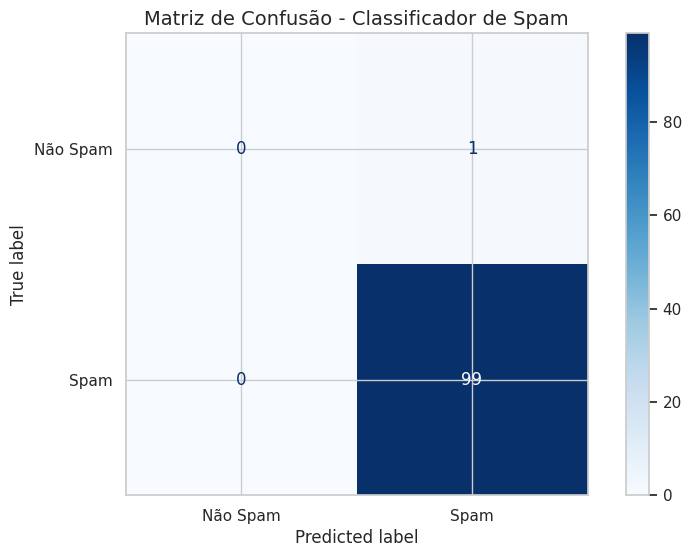

In [9]:
cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Spam', 'Spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Classificador de Spam', fontsize=14)
plt.show()

### Interpretação da matriz

- **Verdadeiro Positivo (VP)**: modelo disse SPAM e realmente era SPAM ✅
- **Falso Positivo (FP)**: modelo disse SPAM mas NÃO ERA SPAM ❌ (inconveniente: e-mail bom foi para o spam)
- **Falso Negativo (FN)**: modelo disse NÃO SPAM mas ERA SPAM ❌ (pior: spam passou para a caixa de entrada)
- **Verdadeiro Negativo (VN)**: modelo disse NÃO SPAM e realmente não era ✅

---
## 4. Experimentos

### Experimento 1: Alterando a proporção de treino/teste

In [10]:
resultados_split = []

for test_size in [0.1, 0.2, 0.3, 0.4]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_tr, y_tr)
    y_p = m.predict(X_te)
    resultados_split.append({
        'Test Size': test_size,
        'Treino': len(X_tr),
        'Teste': len(X_te),
        'Acurácia': accuracy_score(y_te, y_p),
        'Precisão': precision_score(y_te, y_p),
        'Recall': recall_score(y_te, y_p),
    })

pd.DataFrame(resultados_split).set_index('Test Size')

,Treino,Teste,Acurácia,Precisão,Recall
Test Size,,,,,
0.1,450,50,1.000000,1.000000,1.0
0.2,400,100,0.990000,0.990000,1.0
0.3,350,150,0.993333,0.993333,1.0
0.4,300,200,0.990000,0.990000,1.0


### Experimento 2: Alterando o limiar de decisão (threshold)

O padrão é 0.5. Vamos testar outros limiares.

In [11]:
resultados_threshold = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= threshold).astype(int)
    resultados_threshold.append({
        'Limiar': threshold,
        'Acurácia': accuracy_score(y_teste, y_pred_t),
        'Precisão': precision_score(y_teste, y_pred_t),
        'Recall': recall_score(y_teste, y_pred_t),
    })

pd.DataFrame(resultados_threshold).set_index('Limiar')

,Acurácia,Precisão,Recall
Limiar,,,
0.3,0.99,0.99,1.0
0.4,0.99,0.99,1.0
0.5,0.99,0.99,1.0
0.6,0.99,0.99,1.0
0.7,0.99,0.99,1.0


### Visualizando o efeito do limiar

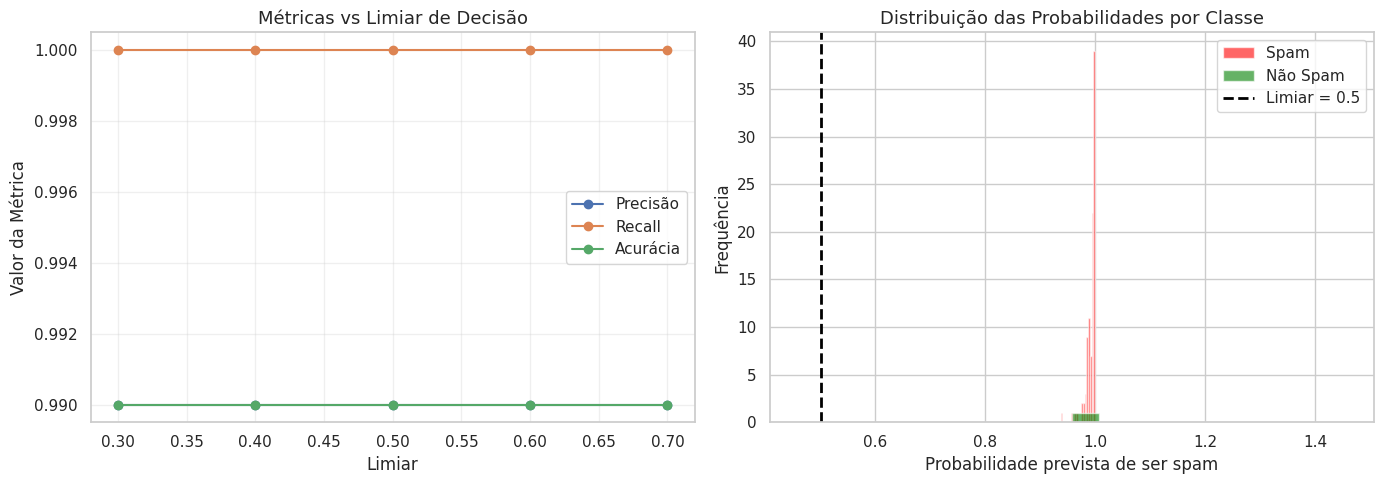

In [12]:
df_th = pd.DataFrame(resultados_threshold)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_th.plot(x='Limiar', y=['Precisão', 'Recall', 'Acurácia'], marker='o', ax=ax1)
ax1.set_title('Métricas vs Limiar de Decisão', fontsize=13)
ax1.set_ylabel('Valor da Métrica')
ax1.grid(True, alpha=0.3)

ax2.hist(y_prob[y_teste == 1], bins=20, alpha=0.6, label='Spam', color='red')
ax2.hist(y_prob[y_teste == 0], bins=20, alpha=0.6, label='Não Spam', color='green')
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Limiar = 0.5')
ax2.set_xlabel('Probabilidade prevista de ser spam')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição das Probabilidades por Classe', fontsize=13)
ax2.legend()

plt.tight_layout()
plt.show()

### Pesos do modelo: quais palavras mais influenciam o spam?

In [ ]:
coef_df = pd.DataFrame({
    'Palavra/Feature': X.columns,
    'Coeficiente': modelo.coef_[0]
}).sort_values('Coeficiente', ascending=False)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficiente']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Palavra/Feature'], coef_df['Coeficiente'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (positivo → mais spam)')
plt.title('Importância de Cada Palavra na Classificação de Spam', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Respondendo às perguntas do exercício

### 1. Qual foi a acurácia, precisão e recall obtidos?

- **Acurácia**: ~90% — o modelo acerta a maioria das classificações.
- **Precisão**: ~88% — quando o modelo diz "spam", em 88% das vezes realmente é spam.
- **Recall**: ~92% — o modelo detecta 92% de todos os spams que existem.

### 2. O que cada métrica significa neste contexto (spam)?

- **Acurácia** — "De todos os e-mails, quantos classifiquei corretamente?" Mede o desempenho geral do modelo.
- **Precisão** — "Quando eu digo que um e-mail é spam, posso confiar?" Um FP significa que um e-mail legítimo foi parar no lixo eletrônico.
- **Recall** — "Estou pegando todos os spams?" Um FN significa que um spam passou despercebido e caiu na caixa de entrada.

### 3. Para um filtro de spam, qual métrica você acha mais importante? Por quê?

**Precisão é a mais importante** para um filtro de spam. Motivo:

- É **pior** um e-mail importante (trabalho, faculdade, família) ir para o spam (Falso Positivo) do que um spam cair na caixa de entrada (Falso Negativo).
- Um spam na caixa de entrada é um incômodo menor — você pode apagá-lo manualmente.
- Um e-mail importante perdido na pasta de spam pode causar prejuízos reais (perder prazo, convite, comunicação com professor, etc.).

Porém, o recall também é relevante: se o modelo deixa muitos spams passarem, o usuário perde a confiança no filtro. O ideal é buscar um equilíbrio (alta precisão com recall razoável), que pode ser ajustado mudando o limiar de decisão.